In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load datasets exported from PostgreSQL
process_df = pd.read_csv("D:\DATA Analysis\Projects\Enterprise AI Transformation & ROI Intelligence Platform___SEM_6\Cleaned CSV\process_cleaned.csv")
project_df = pd.read_csv("D:\DATA Analysis\Projects\Enterprise AI Transformation & ROI Intelligence Platform___SEM_6\Cleaned CSV\project_cleaned.csv")
finance_df = pd.read_csv("D:\DATA Analysis\Projects\Enterprise AI Transformation & ROI Intelligence Platform___SEM_6\Cleaned CSV\finance_cleaned.csv")


## Exploratory data analysis

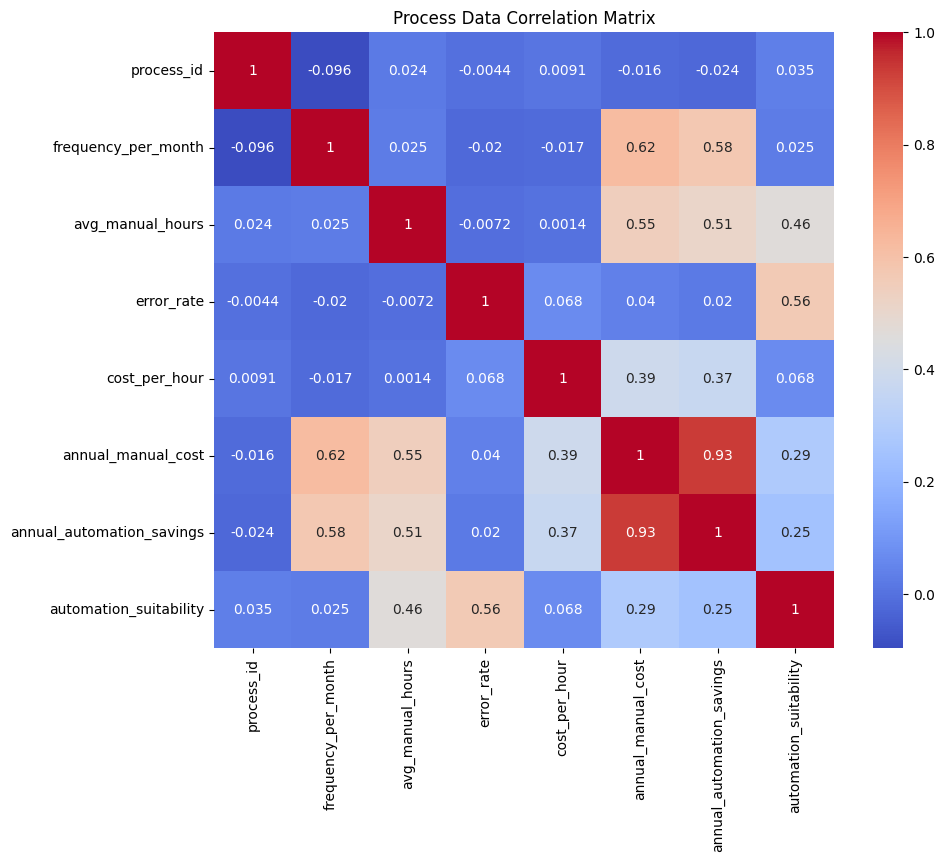

In [6]:
# Correlation Matrix (Process Data)
plt.figure(figsize=(10,8))
sns.heatmap(process_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Process Data Correlation Matrix")
plt.show()


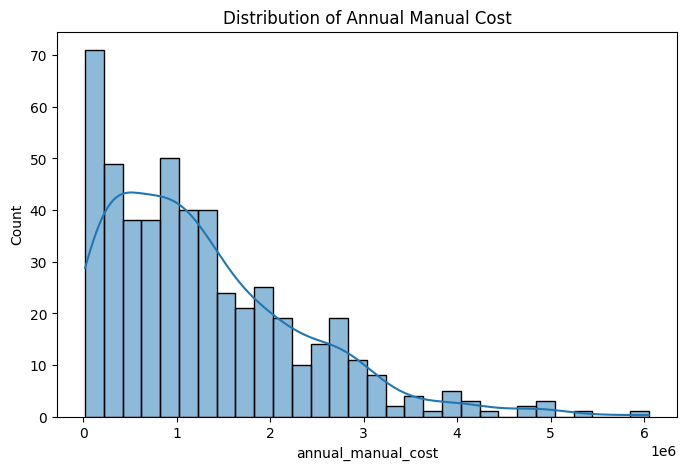

In [7]:
# Distribution of Annual Manual Cost
plt.figure(figsize=(8,5))
sns.histplot(process_df["annual_manual_cost"], bins=30, kde=True)
plt.title("Distribution of Annual Manual Cost")
plt.show()


# MODEL 1 — Automation Suitability Model

In [9]:
# Define features

X_auto = process_df[[
    "frequency_per_month",
    "avg_manual_hours",
    "error_rate",
    "cost_per_hour",
    "annual_manual_cost",
    "annual_automation_savings"
]]

y_auto = process_df["automation_suitability"]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_auto, y_auto, test_size=0.2, random_state=42
)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# Logistic Regression Model

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        58
           1       0.79      0.74      0.77        42

    accuracy                           0.81       100
   macro avg       0.81      0.80      0.80       100
weighted avg       0.81      0.81      0.81       100



In [13]:
# Random Forest Model

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        42

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



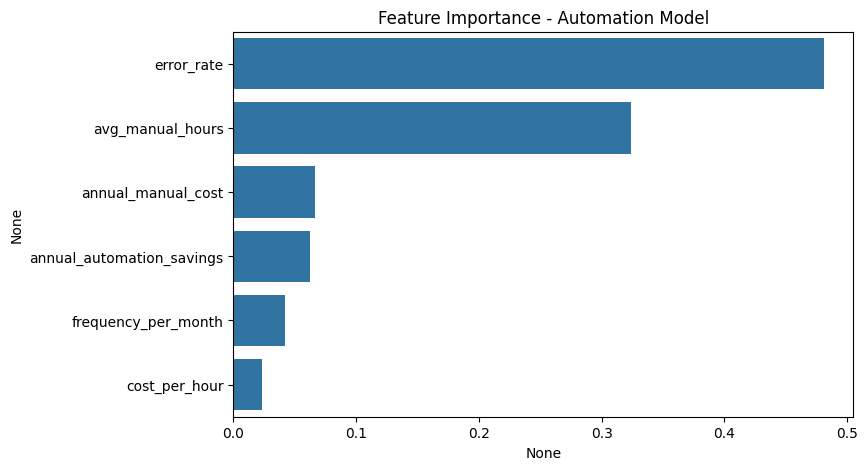

In [14]:
# Feature importance

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_auto.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance - Automation Model")
plt.show()


# MODEL 2 — AI Project Success Prediction

In [15]:
X_proj = project_df[[
    "budget_million_usd",
    "team_size",
    "data_quality_score",
    "infra_readiness_score",
    "leadership_support_score",
    "deployment_time_months",
    "overall_risk_index"
]]

y_proj = project_df["project_success"]


In [16]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_proj, y_proj, test_size=0.2, random_state=42
)


In [17]:
# Random Forest Model

rf_proj = RandomForestClassifier(n_estimators=300, random_state=42)
rf_proj.fit(X_train_p, y_train_p)

proj_pred = rf_proj.predict(X_test_p)

print("Project Success Accuracy:", accuracy_score(y_test_p, proj_pred))
print(classification_report(y_test_p, proj_pred))


Project Success Accuracy: 0.95
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.91      1.00      0.95        21

    accuracy                           0.95        40
   macro avg       0.96      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



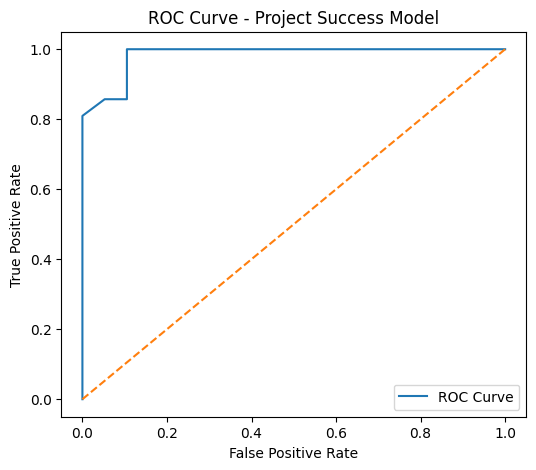

ROC-AUC Score: 0.9837092731829574


In [18]:
# ROC curve

y_prob = rf_proj.predict_proba(X_test_p)[:,1]

fpr, tpr, _ = roc_curve(y_test_p, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - Project Success Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test_p, y_prob))


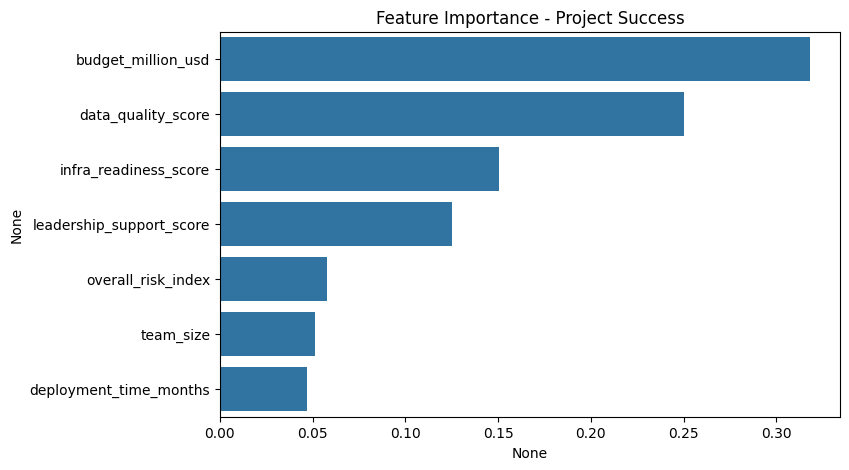

In [19]:
# Feature Importance

importance_proj = pd.Series(
    rf_proj.feature_importances_,
    index=X_proj.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance_proj, y=importance_proj.index)
plt.title("Feature Importance - Project Success")
plt.show()


In [20]:
## ROI analysis in python

finance_df["roi_percentage"] = (
    (finance_df["annual_automation_savings_million"] - 
     finance_df["maintenance_cost_million"]) 
    / finance_df["annual_ai_investment_million"]
) * 100

print(finance_df)


    department  annual_ai_investment_million  \
0      Finance                         18.77   
1           HR                         16.78   
2   Operations                         12.20   
3           IT                         13.83   
4        Sales                         18.17   
5  Procurement                          9.19   

   annual_automation_savings_million  maintenance_cost_million  \
0                              10.19                      2.59   
1                               3.24                      1.03   
2                              21.18                      4.91   
3                              20.62                      1.47   
4                               5.30                      0.80   
5                              15.69                      3.18   

   net_benefit_million  roi_percentage  
0                 7.60       40.490144  
1                 2.21       13.170441  
2                16.27      133.360656  
3                19.15      138.4671

In [21]:
process_df["automation_prediction"] = rf_model.predict(X_auto)
project_df["success_prediction"] = rf_proj.predict(X_proj)

process_df.to_csv("process_with_predictions.csv", index=False)
project_df.to_csv("project_with_predictions.csv", index=False)
